In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# 1. CARGA DE DATOS
# =========================

archivo = "202605_aplazaloh_produccion.xlsx"

df = pd.read_excel(archivo)

df.columns = df.columns.str.strip()

# Normalizar nombre de campaña
if "Campaña" in df.columns:
    df["Campania"] = df["Campaña"]
elif "Campania" not in df.columns:
    raise KeyError("No existe columna Campaña ni Campania")

# =========================
# 2. LIMPIEZA OPERATIVA
# =========================

cols_cero = [
    "Q_LLA",
    "Q_CET",
    "Q_NOC",
    "Q_CTR",
    "Q_CTNR",
    "Q_OFERTA",
    "Q_ACEPTA",
    "Q_VENTAS",
    "Q_MONTO_VENTA",
    "Q_VENTA_REG",
    "MONTO"
]

cols_cero_existentes = [col for col in cols_cero if col in df.columns]

df[cols_cero_existentes] = df[cols_cero_existentes].fillna(0)

# =========================
# 3. CREACIÓN DE HORAS
# =========================

df["T_LOGIN_HORAS"] = df["T_LOGIN"] * 24
df["T_HABLADO_HORAS"] = df["T_HABLADO"] * 24
df["T_PAUSA_HORAS"] = df["T_PAUSA"] * 24
df["T_ESPERA_HORAS"] = df["T_ESPERA"] * 24
df["T_DISPONIBLE_HORAS"] = df["T_DISPONIBLE"] * 24
df["T_ACW_HORAS"] = df["T_ACW"] * 24

# =========================
# 4. BASE ASESOR-DÍA
# =========================

asesor_dia = (
    df
    .groupby(["FECHA", "DNI", "SUPERVISOR", "Campania"], as_index=False)
    .agg({
        "Q_LLA": "max",
        "Q_CET": "max",
        "Q_NOC": "max",
        "Q_CTR": "max",
        "Q_CTNR": "max",
        "Q_OFERTA": "max",
        "Q_ACEPTA": "max",
        "Q_VENTAS": "max",
        "Q_MONTO_VENTA": "max",
        "T_LOGIN_HORAS": "max",
        "T_HABLADO_HORAS": "max",
        "T_PAUSA_HORAS": "max",
        "T_ESPERA_HORAS": "max",
        "T_DISPONIBLE_HORAS": "max",
        "T_ACW_HORAS": "max"
    })
)

# =========================
# 5. BASE SUPERVISOR-DÍA
# =========================

supervisor_dia = (
    asesor_dia
    .groupby(["FECHA", "SUPERVISOR", "Campania"], as_index=False)
    .agg({
        "DNI": "nunique",
        "Q_LLA": "sum",
        "Q_CET": "sum",
        "Q_NOC": "sum",
        "Q_CTR": "sum",
        "Q_CTNR": "sum",
        "Q_OFERTA": "sum",
        "Q_ACEPTA": "sum",
        "Q_VENTAS": "sum",
        "Q_MONTO_VENTA": "sum",
        "T_LOGIN_HORAS": "sum",
        "T_HABLADO_HORAS": "sum",
        "T_PAUSA_HORAS": "sum",
        "T_ESPERA_HORAS": "sum",
        "T_DISPONIBLE_HORAS": "sum",
        "T_ACW_HORAS": "sum"
    })
    .rename(columns={"DNI": "Q_ASESORES_ACTIVOS"})
)

# =========================
# 6. VARIABLES DERIVADAS
# =========================

def safe_div(num, den):
    return np.where(den == 0, np.nan, num / den)

supervisor_dia["Pct_Hablado"] = safe_div(supervisor_dia["T_HABLADO_HORAS"], supervisor_dia["T_LOGIN_HORAS"])
supervisor_dia["Pct_Pausa"] = safe_div(supervisor_dia["T_PAUSA_HORAS"], supervisor_dia["T_LOGIN_HORAS"])
supervisor_dia["Pct_ACW"] = safe_div(supervisor_dia["T_ACW_HORAS"], supervisor_dia["T_LOGIN_HORAS"])

supervisor_dia["Contactabilidad"] = safe_div(supervisor_dia["Q_CET"], supervisor_dia["Q_LLA"])
supervisor_dia["No_Contacto_Rate"] = safe_div(supervisor_dia["Q_NOC"], supervisor_dia["Q_LLA"])
supervisor_dia["CTR_Rate"] = safe_div(supervisor_dia["Q_CTR"], supervisor_dia["Q_LLA"])
supervisor_dia["CTNR_Rate"] = safe_div(supervisor_dia["Q_CTNR"], supervisor_dia["Q_LLA"])
supervisor_dia["Oferta_Rate"] = safe_div(supervisor_dia["Q_OFERTA"], supervisor_dia["Q_LLA"])
supervisor_dia["Acepta_Rate"] = safe_div(supervisor_dia["Q_ACEPTA"], supervisor_dia["Q_OFERTA"])

supervisor_dia["Llamadas_por_Hora"] = safe_div(supervisor_dia["Q_LLA"], supervisor_dia["T_LOGIN_HORAS"])
supervisor_dia["Contactos_por_Hora"] = safe_div(supervisor_dia["Q_CET"], supervisor_dia["T_LOGIN_HORAS"])

supervisor_dia["Llamadas_por_Asesor"] = safe_div(supervisor_dia["Q_LLA"], supervisor_dia["Q_ASESORES_ACTIVOS"])
supervisor_dia["Contactos_por_Asesor"] = safe_div(supervisor_dia["Q_CET"], supervisor_dia["Q_ASESORES_ACTIVOS"])

supervisor_dia["NRO_DIA_SEMANA"] = supervisor_dia["FECHA"].dt.weekday + 1
supervisor_dia["NRO_QUINCENA"] = np.where(supervisor_dia["FECHA"].dt.day <= 15, 1, 2)

# =========================
# 7. BASE DE MODELO
# =========================

y_col = "Q_VENTAS"

variables_candidatas = [
    "Q_ASESORES_ACTIVOS",
    "Q_LLA",
    "Q_CET",
    "Q_NOC",
    "Q_CTR",
    "Q_CTNR",
    "Q_OFERTA",
    "Q_ACEPTA",
    "T_LOGIN_HORAS",
    "T_HABLADO_HORAS",
    "T_PAUSA_HORAS",
    "T_ESPERA_HORAS",
    "T_DISPONIBLE_HORAS",
    "T_ACW_HORAS",
    "Pct_Hablado",
    "Pct_Pausa",
    "Pct_ACW",
    "Contactabilidad",
    "No_Contacto_Rate",
    "CTR_Rate",
    "CTNR_Rate",
    "Oferta_Rate",
    "Acepta_Rate",
    "Llamadas_por_Hora",
    "Contactos_por_Hora",
    "Llamadas_por_Asesor",
    "Contactos_por_Asesor",
    "NRO_DIA_SEMANA",
    "NRO_QUINCENA"
]

cols_modelo = [y_col] + variables_candidatas

faltantes = [col for col in cols_modelo if col not in supervisor_dia.columns]

if faltantes:
    raise KeyError(f"Faltan columnas en supervisor_dia: {faltantes}")

df_modelo = supervisor_dia[cols_modelo].copy()

df_modelo = df_modelo.replace([np.inf, -np.inf], np.nan)
df_modelo = df_modelo.fillna(0)

cols_constantes = df_modelo.columns[df_modelo.nunique() <= 1].tolist()

df_modelo_reg = df_modelo.drop(columns=cols_constantes)

correlaciones = df_modelo_reg.corr(numeric_only=True)[y_col].sort_values(ascending=False)

print("df:", df.shape)
print("asesor_dia:", asesor_dia.shape)
print("supervisor_dia:", supervisor_dia.shape)
print("df_modelo:", df_modelo.shape)
print("df_modelo_reg:", df_modelo_reg.shape)
print("Columnas constantes eliminadas:", cols_constantes)

df: (6138, 59)
asesor_dia: (698, 19)
supervisor_dia: (52, 34)
df_modelo: (52, 30)
df_modelo_reg: (52, 24)
Columnas constantes eliminadas: ['Q_CTNR', 'Q_OFERTA', 'Q_ACEPTA', 'CTNR_Rate', 'Oferta_Rate', 'Acepta_Rate']


In [3]:
correlaciones

Q_VENTAS                1.000000
T_HABLADO_HORAS         0.950062
Q_LLA                   0.912245
Q_ASESORES_ACTIVOS      0.904126
Q_NOC                   0.893079
T_LOGIN_HORAS           0.885706
Q_CET                   0.879877
Q_CTR                   0.870514
T_ESPERA_HORAS          0.869195
T_ACW_HORAS             0.859000
T_DISPONIBLE_HORAS      0.853140
T_PAUSA_HORAS           0.804618
CTR_Rate                0.637934
Llamadas_por_Asesor     0.421927
No_Contacto_Rate        0.395935
Pct_ACW                 0.325380
Pct_Pausa               0.152106
Pct_Hablado             0.130493
NRO_QUINCENA            0.000841
Llamadas_por_Hora      -0.040129
Contactos_por_Asesor   -0.112001
NRO_DIA_SEMANA         -0.242810
Contactos_por_Hora     -0.317415
Contactabilidad        -0.465940
Name: Q_VENTAS, dtype: float64

In [4]:
correlaciones.head(15)

Q_VENTAS               1.000000
T_HABLADO_HORAS        0.950062
Q_LLA                  0.912245
Q_ASESORES_ACTIVOS     0.904126
Q_NOC                  0.893079
T_LOGIN_HORAS          0.885706
Q_CET                  0.879877
Q_CTR                  0.870514
T_ESPERA_HORAS         0.869195
T_ACW_HORAS            0.859000
T_DISPONIBLE_HORAS     0.853140
T_PAUSA_HORAS          0.804618
CTR_Rate               0.637934
Llamadas_por_Asesor    0.421927
No_Contacto_Rate       0.395935
Name: Q_VENTAS, dtype: float64

In [5]:
correlaciones.tail(15)

T_ACW_HORAS             0.859000
T_DISPONIBLE_HORAS      0.853140
T_PAUSA_HORAS           0.804618
CTR_Rate                0.637934
Llamadas_por_Asesor     0.421927
No_Contacto_Rate        0.395935
Pct_ACW                 0.325380
Pct_Pausa               0.152106
Pct_Hablado             0.130493
NRO_QUINCENA            0.000841
Llamadas_por_Hora      -0.040129
Contactos_por_Asesor   -0.112001
NRO_DIA_SEMANA         -0.242810
Contactos_por_Hora     -0.317415
Contactabilidad        -0.465940
Name: Q_VENTAS, dtype: float64

In [6]:
df_modelo_reg.columns

Index(['Q_VENTAS', 'Q_ASESORES_ACTIVOS', 'Q_LLA', 'Q_CET', 'Q_NOC', 'Q_CTR',
       'T_LOGIN_HORAS', 'T_HABLADO_HORAS', 'T_PAUSA_HORAS', 'T_ESPERA_HORAS',
       'T_DISPONIBLE_HORAS', 'T_ACW_HORAS', 'Pct_Hablado', 'Pct_Pausa',
       'Pct_ACW', 'Contactabilidad', 'No_Contacto_Rate', 'CTR_Rate',
       'Llamadas_por_Hora', 'Contactos_por_Hora', 'Llamadas_por_Asesor',
       'Contactos_por_Asesor', 'NRO_DIA_SEMANA', 'NRO_QUINCENA'],
      dtype='object')

In [7]:
vars_volumen = [
    "Q_ASESORES_ACTIVOS",
    "Q_LLA",
    "Q_CET",
    "Q_NOC",
    "Q_CTR"
]

X = df_modelo_reg[vars_volumen]
y = df_modelo_reg["Q_VENTAS"]

X_const = sm.add_constant(X)

modelo_volumen = sm.OLS(y, X_const).fit()

print(modelo_volumen.summary())

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     48.43
Date:                Wed, 13 May 2026   Prob (F-statistic):           3.29e-17
Time:                        10:59:23   Log-Likelihood:                -148.68
No. Observations:                  52   AIC:                             309.4
Df Residuals:                      46   BIC:                             321.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.9572      1

In [8]:
vars_tiempo = [
    "Q_ASESORES_ACTIVOS",
    "T_LOGIN_HORAS",
    "T_HABLADO_HORAS",
    "T_PAUSA_HORAS",
    "T_ESPERA_HORAS",
    "T_DISPONIBLE_HORAS",
    "T_ACW_HORAS"
]

vars_tiempo = [v for v in vars_tiempo if v in df_modelo_reg.columns]

X = df_modelo_reg[vars_tiempo]
y = df_modelo_reg["Q_VENTAS"]

X_const = sm.add_constant(X)

modelo_tiempo = sm.OLS(y, X_const).fit()

print(modelo_tiempo.summary())

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     110.4
Date:                Wed, 13 May 2026   Prob (F-statistic):           8.88e-26
Time:                        10:59:28   Log-Likelihood:                -120.43
No. Observations:                  52   AIC:                             256.9
Df Residuals:                      44   BIC:                             272.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.3126      1

In [9]:
vars_eficiencia = [
    "Q_ASESORES_ACTIVOS",
    "Pct_Hablado",
    "Pct_Pausa",
    "Pct_ACW",
    "Contactabilidad",
    "No_Contacto_Rate",
    "CTR_Rate",
    "Llamadas_por_Hora",
    "Contactos_por_Hora",
    "Llamadas_por_Asesor",
    "Contactos_por_Asesor",
    "NRO_DIA_SEMANA",
    "NRO_QUINCENA"
]

vars_eficiencia = [v for v in vars_eficiencia if v in df_modelo_reg.columns]

X = df_modelo_reg[vars_eficiencia]
y = df_modelo_reg["Q_VENTAS"]

X_const = sm.add_constant(X)

modelo_eficiencia = sm.OLS(y, X_const).fit()

print(modelo_eficiencia.summary())

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     31.98
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.92e-16
Time:                        10:59:32   Log-Likelihood:                -131.90
No. Observations:                  52   AIC:                             291.8
Df Residuals:                      38   BIC:                             319.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   38.4684 

In [10]:
comparacion_modelos = pd.DataFrame({
    "Modelo": ["Volumen", "Tiempo", "Eficiencia"],
    "Variables": [
        len(vars_volumen),
        len(vars_tiempo),
        len(vars_eficiencia)
    ],
    "R2": [
        modelo_volumen.rsquared,
        modelo_tiempo.rsquared,
        modelo_eficiencia.rsquared
    ],
    "R2_Ajustado": [
        modelo_volumen.rsquared_adj,
        modelo_tiempo.rsquared_adj,
        modelo_eficiencia.rsquared_adj
    ],
    "AIC": [
        modelo_volumen.aic,
        modelo_tiempo.aic,
        modelo_eficiencia.aic
    ],
    "BIC": [
        modelo_volumen.bic,
        modelo_tiempo.bic,
        modelo_eficiencia.bic
    ]
})

comparacion_modelos.sort_values(by="R2_Ajustado", ascending=False)

,Modelo,Variables,R2,R2_Ajustado,AIC,BIC
1,Tiempo,7,0.946136,0.937566,256.856930,272.466880
2,Eficiencia,13,0.916257,0.887608,291.803412,319.120824
0,Volumen,5,0.840356,0.823004,309.353516,321.060978


In [11]:
def resumen_coeficientes(modelo, nombre_modelo):
    tabla = pd.DataFrame({
        "Variable": modelo.params.index,
        "Coeficiente": modelo.params.values,
        "P_value": modelo.pvalues.values,
        "Modelo": nombre_modelo
    })
    
    tabla = tabla[tabla["Variable"] != "const"]
    tabla["Significativa_5pct"] = tabla["P_value"] < 0.05
    
    return tabla.sort_values(by="P_value")

resumen_volumen = resumen_coeficientes(modelo_volumen, "Volumen")
resumen_tiempo = resumen_coeficientes(modelo_tiempo, "Tiempo")
resumen_eficiencia = resumen_coeficientes(modelo_eficiencia, "Eficiencia")

resumen_coef = pd.concat(
    [resumen_volumen, resumen_tiempo, resumen_eficiencia],
    ignore_index=True
)

resumen_coef

,Variable,Coeficiente,P_value,Modelo,Significativa_5pct
0,Q_LLA,0.065457,1.268546e-01,Volumen,False
1,Q_CET,-0.046032,2.607809e-01,Volumen,False
2,Q_NOC,-0.035312,3.295759e-01,Volumen,False
3,Q_ASESORES_ACTIVOS,0.183678,7.356301e-01,Volumen,False
4,Q_CTR,-0.000920,9.859877e-01,Volumen,False
5,T_HABLADO_HORAS,5.585319,4.672380e-12,Tiempo,True
6,T_ACW_HORAS,-3.616463,1.385107e-04,Tiempo,True
7,Q_ASESORES_ACTIVOS,-0.874351,5.271830e-02,Tiempo,False
8,T_ESPERA_HORAS,0.545325,2.543277e-01,Tiempo,False
9,T_DISPONIBLE_HORAS,-0.553151,6.455793e-01,Tiempo,False


In [12]:
resumen_coef[resumen_coef["Significativa_5pct"] == True]

,Variable,Coeficiente,P_value,Modelo,Significativa_5pct
5,T_HABLADO_HORAS,5.585319,4.672380e-12,Tiempo,True
6,T_ACW_HORAS,-3.616463,1.385107e-04,Tiempo,True
12,Q_ASESORES_ACTIVOS,1.146922,8.090252e-07,Eficiencia,True
13,Pct_Hablado,85.872242,2.604023e-05,Eficiencia,True
14,Contactos_por_Asesor,1.561629,1.113245e-02,Eficiencia,True
15,Contactabilidad,-78.169220,3.367303e-02,Eficiencia,True


In [13]:
from sklearn.preprocessing import StandardScaler

vars_final = vars_tiempo

X = df_modelo_reg[vars_final].copy()
y = df_modelo_reg["Q_VENTAS"].copy()

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

X_scaled = pd.DataFrame(X_scaled, columns=vars_final)

X_scaled_const = sm.add_constant(X_scaled)

modelo_tiempo_std = sm.OLS(y_scaled, X_scaled_const).fit()

coef_std_tiempo = pd.DataFrame({
    "Variable": modelo_tiempo_std.params.index,
    "Coef_Estandarizado": modelo_tiempo_std.params.values,
    "P_value": modelo_tiempo_std.pvalues.values
})

coef_std_tiempo = coef_std_tiempo[coef_std_tiempo["Variable"] != "const"]

coef_std_tiempo["Impacto_Absoluto"] = coef_std_tiempo["Coef_Estandarizado"].abs()

coef_std_tiempo = coef_std_tiempo.sort_values(
    by="Impacto_Absoluto",
    ascending=False
)

coef_std_tiempo

,Variable,Coef_Estandarizado,P_value,Impacto_Absoluto
3,T_HABLADO_HORAS,1.898031,4.672380e-12,1.898031
7,T_ACW_HORAS,-0.615390,1.385107e-04,0.615390
1,Q_ASESORES_ACTIVOS,-0.582063,5.271830e-02,0.582063
5,T_ESPERA_HORAS,0.185195,2.543277e-01,0.185195
2,T_LOGIN_HORAS,0.086423,7.896593e-01,0.086423
6,T_DISPONIBLE_HORAS,-0.066192,6.455793e-01,0.066192
4,T_PAUSA_HORAS,0.020782,9.055061e-01,0.020782


In [14]:
vars_tiempo_simple = [
    "T_HABLADO_HORAS",
    "T_ACW_HORAS"
]

X = df_modelo_reg[vars_tiempo_simple]
y = df_modelo_reg["Q_VENTAS"]

X_const = sm.add_constant(X)

modelo_tiempo_simple = sm.OLS(y, X_const).fit()

print(modelo_tiempo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     381.3
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.35e-30
Time:                        10:59:54   Log-Likelihood:                -123.40
No. Observations:                  52   AIC:                             252.8
Df Residuals:                      49   BIC:                             258.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3293      0.722     

In [15]:
comparacion_tiempo = pd.DataFrame({
    "Modelo": ["Tiempo completo", "Tiempo simple"],
    "Variables": [len(vars_tiempo), len(vars_tiempo_simple)],
    "R2": [modelo_tiempo.rsquared, modelo_tiempo_simple.rsquared],
    "R2_Ajustado": [modelo_tiempo.rsquared_adj, modelo_tiempo_simple.rsquared_adj],
    "AIC": [modelo_tiempo.aic, modelo_tiempo_simple.aic],
    "BIC": [modelo_tiempo.bic, modelo_tiempo_simple.bic]
})

comparacion_tiempo

,Modelo,Variables,R2,R2_Ajustado,AIC,BIC
0,Tiempo completo,7,0.946136,0.937566,256.856930,272.466880
1,Tiempo simple,2,0.939624,0.937160,252.790783,258.644514


In [16]:
print(modelo_tiempo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     381.3
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.35e-30
Time:                        11:00:00   Log-Likelihood:                -123.40
No. Observations:                  52   AIC:                             252.8
Df Residuals:                      49   BIC:                             258.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3293      0.722     

In [17]:
resumen_simple = pd.DataFrame({
    "Variable": modelo_tiempo_simple.params.index,
    "Coeficiente": modelo_tiempo_simple.params.values,
    "P_value": modelo_tiempo_simple.pvalues.values
})

resumen_simple

,Variable,Coeficiente,P_value
0,const,-0.329279,6.502511e-01
1,T_HABLADO_HORAS,4.749583,3.068142e-17
2,T_ACW_HORAS,-4.062390,1.462797e-06


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

vars_tiempo_simple = [
    "T_HABLADO_HORAS",
    "T_ACW_HORAS"
]

X_simple = df_modelo_reg[vars_tiempo_simple]
y_simple = df_modelo_reg["Q_VENTAS"]

X_simple_const = sm.add_constant(X_simple)

modelo_tiempo_simple = sm.OLS(y_simple, X_simple_const).fit()

df_plot = X_simple.copy()
df_plot["Q_VENTAS_REAL"] = y_simple
df_plot["Q_VENTAS_PRED"] = modelo_tiempo_simple.predict(X_simple_const)
df_plot["RESIDUO"] = df_plot["Q_VENTAS_REAL"] - df_plot["Q_VENTAS_PRED"]

print(modelo_tiempo_simple.summary())
df_plot.head()

                            OLS Regression Results                            
Dep. Variable:               Q_VENTAS   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     381.3
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.35e-30
Time:                        11:00:10   Log-Likelihood:                -123.40
No. Observations:                  52   AIC:                             252.8
Df Residuals:                      49   BIC:                             258.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.3293      0.722     

,T_HABLADO_HORAS,T_ACW_HORAS,Q_VENTAS_REAL,Q_VENTAS_PRED,RESIDUO
0,10.886904,5.003304,32.0,31.053604,0.946396
1,4.382088,2.696496,12.0,9.529593,2.470407
2,7.958928,3.624840,21.0,22.746797,-1.746797
3,6.252312,2.676216,13.0,18.494763,-5.494763
4,9.967800,4.599456,27.0,28.328831,-1.328831


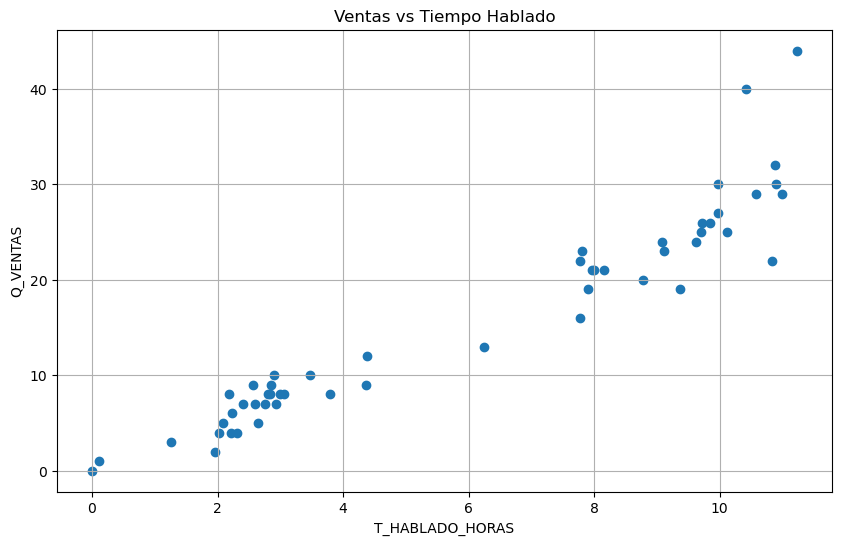

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["T_HABLADO_HORAS"], df_plot["Q_VENTAS_REAL"])
plt.xlabel("T_HABLADO_HORAS")
plt.ylabel("Q_VENTAS")
plt.title("Ventas vs Tiempo Hablado")
plt.grid(True)
plt.savefig(images_path / "03_sales_vs_talk_time.png", dpi=300, bbox_inches="tight")
plt.show()

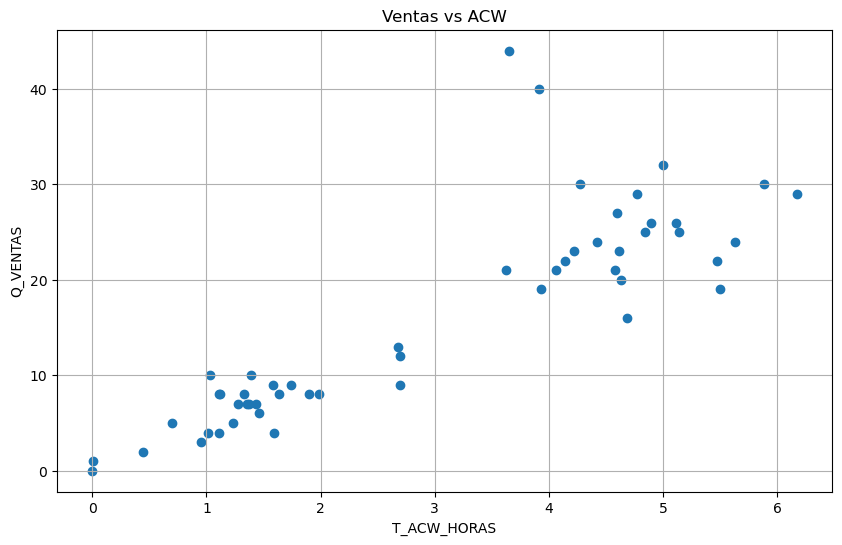

In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["T_ACW_HORAS"], df_plot["Q_VENTAS_REAL"])
plt.xlabel("T_ACW_HORAS")
plt.ylabel("Q_VENTAS")
plt.title("Ventas vs ACW")
plt.grid(True)
plt.savefig(images_path / "04_sales_vs_acw.png", dpi=300, bbox_inches="tight")
plt.show()

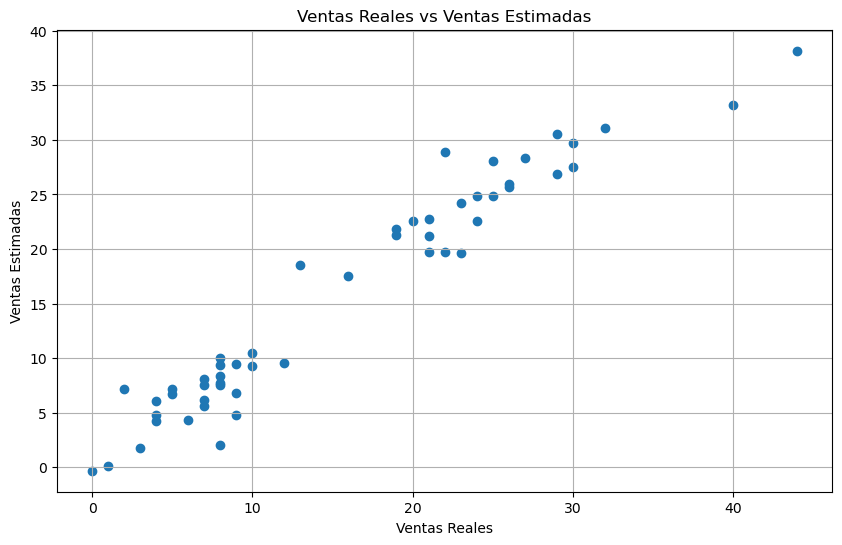

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["Q_VENTAS_REAL"], df_plot["Q_VENTAS_PRED"])
plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Estimadas")
plt.title("Ventas Reales vs Ventas Estimadas")
plt.grid(True)
plt.savefig(images_path / "05_actual_vs_predicted_sales.png", dpi=300, bbox_inches="tight")
plt.show()

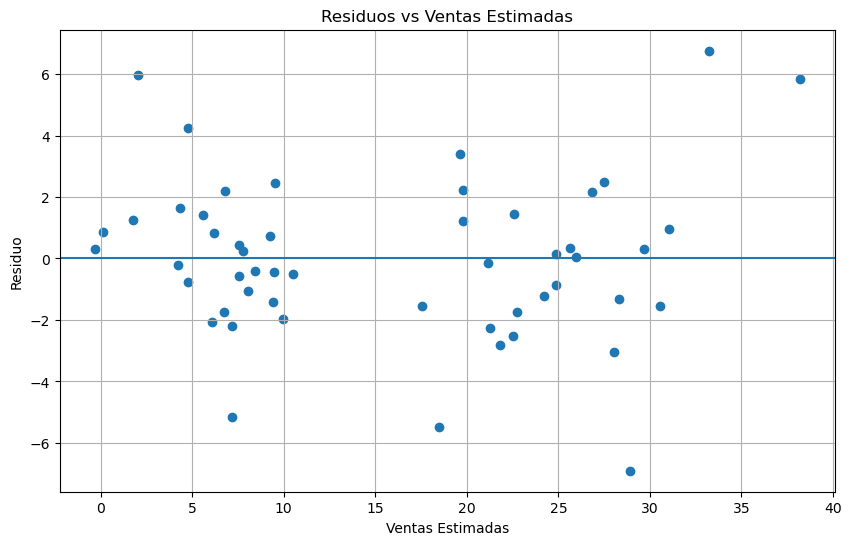

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["Q_VENTAS_PRED"], df_plot["RESIDUO"])
plt.axhline(y=0)
plt.xlabel("Ventas Estimadas")
plt.ylabel("Residuo")
plt.title("Residuos vs Ventas Estimadas")
plt.grid(True)
plt.show()

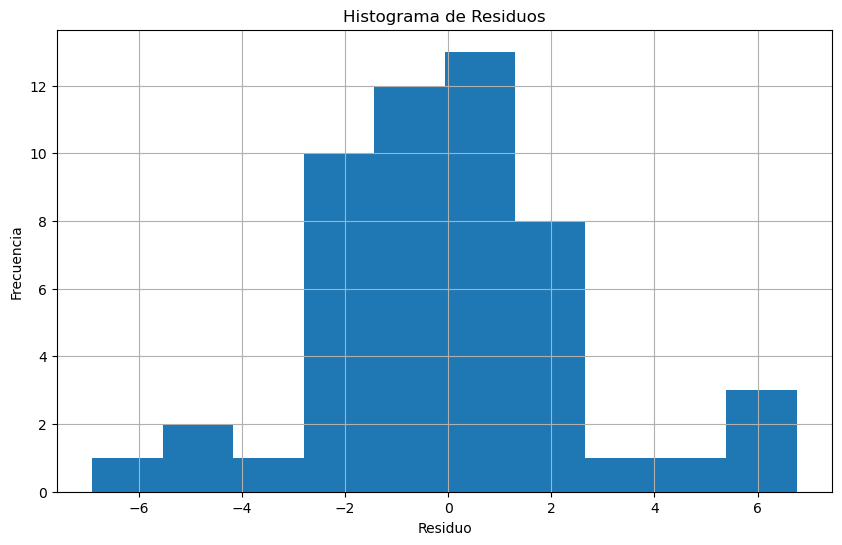

In [37]:
plt.figure(figsize=(10, 6))
plt.hist(df_plot["RESIDUO"], bins=10)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Histograma de Residuos")
plt.grid(True)
plt.savefig(images_path / "06_residual_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
df_plot[["T_HABLADO_HORAS", "T_ACW_HORAS", "Q_VENTAS_REAL", "Q_VENTAS_PRED", "RESIDUO"]].head(10)

,T_HABLADO_HORAS,T_ACW_HORAS,Q_VENTAS_REAL,Q_VENTAS_PRED,RESIDUO
0,10.886904,5.003304,32.0,31.053604,0.946396
1,4.382088,2.696496,12.0,9.529593,2.470407
2,7.958928,3.624840,21.0,22.746797,-1.746797
3,6.252312,2.676216,13.0,18.494763,-5.494763
4,9.967800,4.599456,27.0,28.328831,-1.328831
5,3.794616,1.898208,8.0,9.982303,-1.982303
6,0.004152,0.000000,0.0,-0.309559,0.309559
7,10.585056,4.771464,29.0,30.561776,-1.561776
8,4.364904,2.696304,9.0,9.448756,-0.448756
9,11.000520,6.171432,29.0,26.847841,2.152159


In [24]:
modelo_tiempo_simple.params

const             -0.329279
T_HABLADO_HORAS    4.749583
T_ACW_HORAS       -4.062390
dtype: float64

In [26]:
from pathlib import Path

Path.cwd()

WindowsPath('C:/Users/DARWINCAMACHOHERRERA/Documents/jupyter_lab')

In [27]:
from pathlib import Path

images_path = Path("images")
images_path.mkdir(parents=True, exist_ok=True)

images_path

WindowsPath('images')

In [32]:
list(images_path.glob("*.png"))

[WindowsPath('images/03_sales_vs_talk_time.png'),
 WindowsPath('images/04_sales_vs_acw.png'),
 WindowsPath('images/05_actual_vs_predicted_sales.png')]

In [33]:
from pathlib import Path

images_path = Path("images")
images_path.mkdir(parents=True, exist_ok=True)

In [34]:
comparacion_modelos

,Modelo,Variables,R2,R2_Ajustado,AIC,BIC
0,Volumen,5,0.840356,0.823004,309.353516,321.060978
1,Tiempo,7,0.946136,0.937566,256.856930,272.466880
2,Eficiencia,13,0.916257,0.887608,291.803412,319.120824


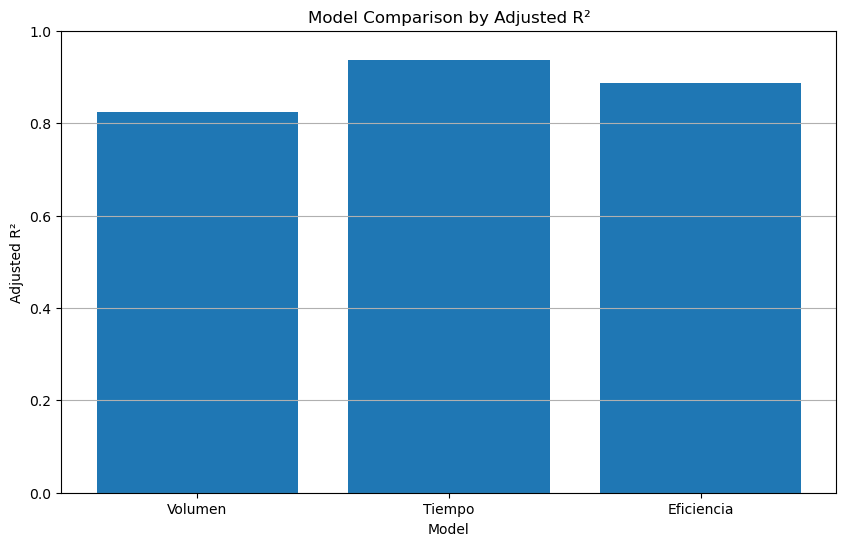

In [35]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparacion_modelos["Modelo"],
    comparacion_modelos["R2_Ajustado"]
)

plt.title("Model Comparison by Adjusted R²")
plt.xlabel("Model")
plt.ylabel("Adjusted R²")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.savefig(images_path / "01_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

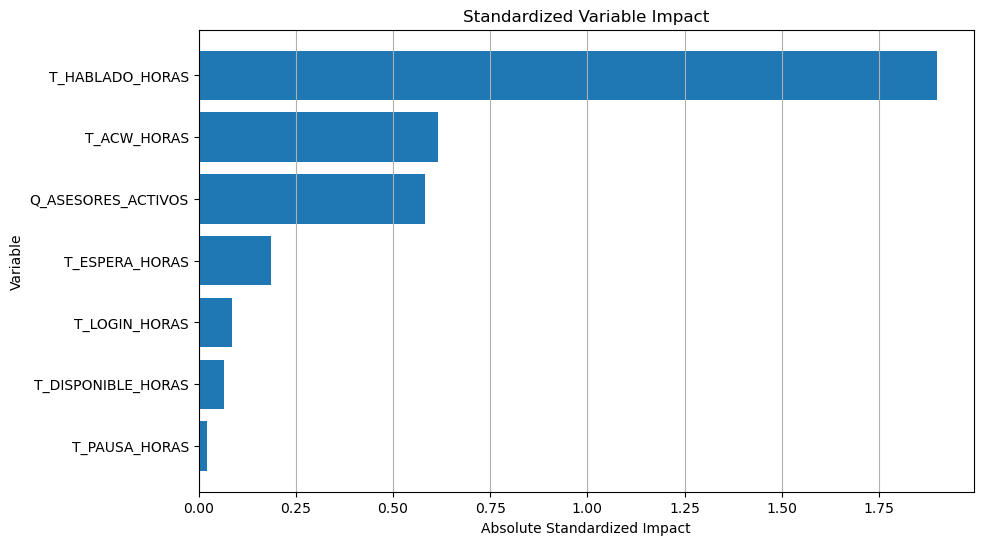

In [36]:
coef_plot = coef_std_tiempo.sort_values("Impacto_Absoluto", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    coef_plot["Variable"],
    coef_plot["Impacto_Absoluto"]
)

plt.title("Standardized Variable Impact")
plt.xlabel("Absolute Standardized Impact")
plt.ylabel("Variable")
plt.grid(axis="x")

plt.savefig(images_path / "02_standardized_variable_impact.png", dpi=300, bbox_inches="tight")
plt.show()